Вариант 23

# 1. Одномерная выборка

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

OD_PATH = "./data/One-dimensional_sampling.csv"

OD_data = pd.read_csv(OD_PATH, header=None)
OD_data = OD_data.T
OD_data.columns = ["OD_Values"]
OD_data["OD_Values"] = OD_data["OD_Values"].astype("float64")

print(OD_data.head())
print(f"Shape: {OD_data.shape}")

   OD_Values
0      -3.48
1       6.28
2      -2.59
3      -2.04
4       5.72
Shape: (100, 1)


## 1.1 Получение вариационного ряда

In [2]:
sorted_values = np.sort(OD_data["OD_Values"])
sorted_values.flatten()

array([-3.48, -2.59, -2.23, -2.12, -2.04, -1.84, -1.79, -1.05, -0.78,
       -0.73, -0.42, -0.13, -0.1 , -0.  , -0.  ,  0.  ,  0.07,  0.09,
        0.24,  0.27,  0.29,  0.34,  0.38,  0.45,  0.66,  0.8 ,  0.8 ,
        1.02,  1.02,  1.2 ,  1.29,  1.3 ,  1.69,  1.76,  2.01,  2.01,
        2.12,  2.19,  2.31,  2.33,  2.34,  2.35,  2.4 ,  2.43,  2.53,
        2.56,  2.57,  2.6 ,  2.64,  2.78,  2.92,  2.97,  2.97,  3.21,
        3.3 ,  3.36,  3.51,  3.52,  3.56,  3.58,  3.6 ,  3.61,  3.75,
        3.84,  3.87,  3.95,  4.05,  4.21,  4.22,  4.33,  4.33,  4.36,
        4.4 ,  4.47,  4.47,  4.55,  4.83,  4.97,  4.97,  5.03,  5.05,
        5.09,  5.22,  5.35,  5.4 ,  5.44,  5.72,  5.79,  6.28,  6.29,
        6.78,  6.79,  6.88,  6.96,  7.07,  7.3 ,  7.6 ,  7.62,  7.84,
        7.89])

## 1.2 Построить график эмпирической функции распределения $F^*(x)$
Для построения графика эмпирической функции распределения $F^*(x)$, нужно:
1. Отсортировать значения выборки по возрастанию.
2. Для каждого уникального значения $x_i$ вычислить долю наблюдений, меньших или равных $x_i$.
3. Построить ступенчатую функцию, соединяющую точки $(x_i, F^*(x_i))$

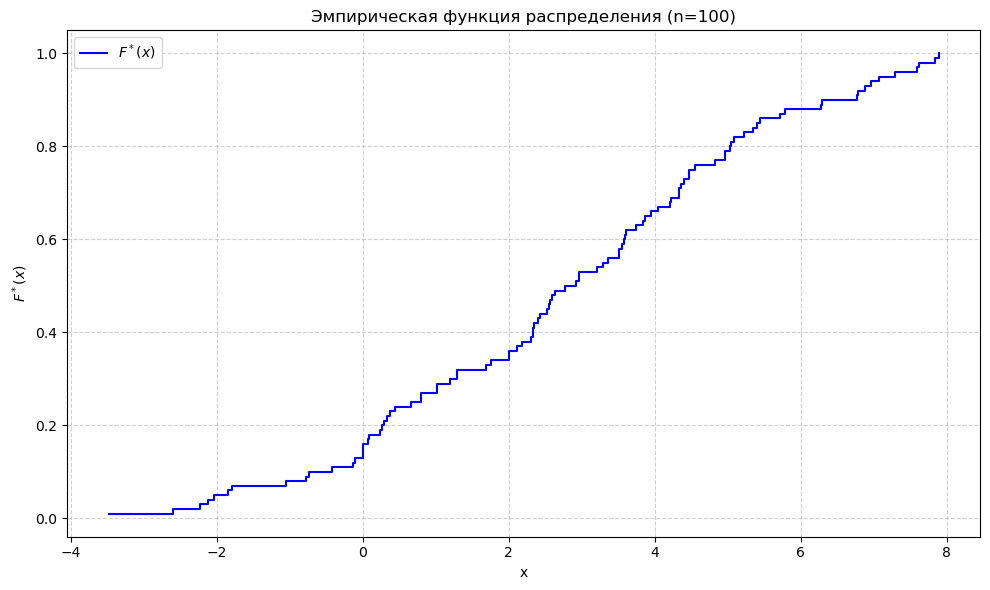

In [3]:
n = len(sorted_values)
y_vals = np.arange(1, n + 1) / n

plt.figure(figsize=(10, 6))
plt.step(sorted_values, y_vals, where='post', label=r'$F^*(x)$', color='blue')
plt.xlabel('x')
plt.ylabel(r'$F^*(x)$')
plt.title(f'Эмпирическая функция распределения (n={n})')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
# plt.plot([-4, 8], [0, 1])
plt.show()

## 1.2 Построить гистограмму равноинтервальным способом;
Для построения гистограммы равноинтервальным способом нужно:

1. Разделить диапазон значений на равные интервалы (бин/ы).
2. Посчитать, сколько значений попало в каждый бин.
3. Построить столбцы высотой, пропорциональной частоте (или плотности) попадания в каждый бин.

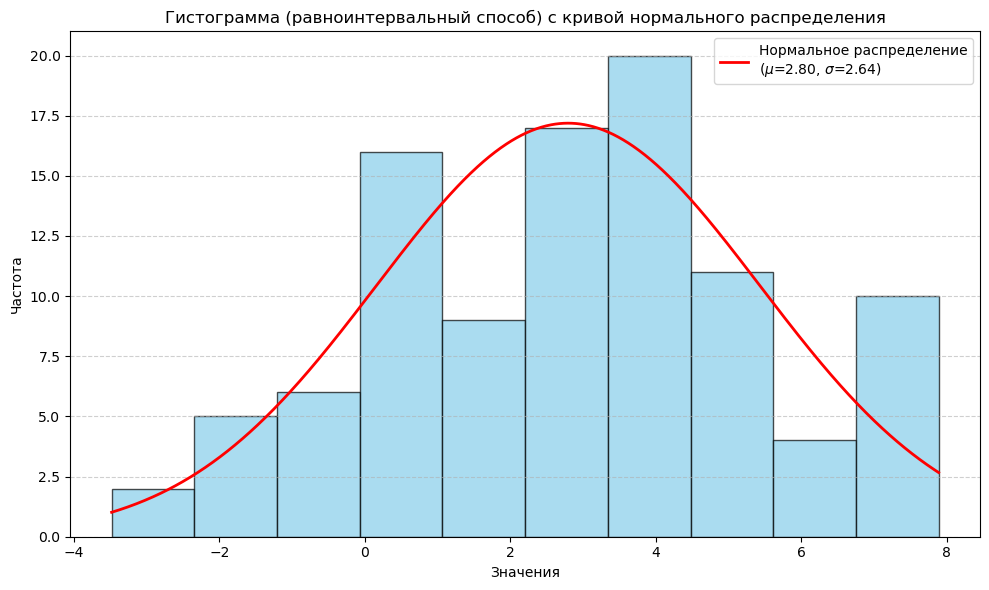

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

data = OD_data["OD_Values"]

plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(data, bins=10, edgecolor='black', density=False, color='skyblue', alpha=0.7)

mu = np.mean(data)
sigma = np.std(data, ddof=1)

x = np.linspace(data.min(), data.max(), 1000)
pdf = norm.pdf(x, mu, sigma)

bin_width = bins[1] - bins[0]
scaled_pdf = pdf * len(data) * bin_width

plt.plot(x, scaled_pdf, 'r-', linewidth=2, label=f'Нормальное распределение\n($\mu$={mu:.2f}, $\sigma$={sigma:.2f})')

plt.title('Гистограмма (равноинтервальный способ) с кривой нормального распределения')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 1.3 Построить гистограмму равновероятностным способом

1. Разделить отсортированную выборку на равные по количеству наблюдений группы (например, 10 групп по 10% данных в каждой).
2. Границы этих групп станут границами бинов.
3. Все бины будут иметь равную высоту, т.к. содержат одинаковое количество данных.

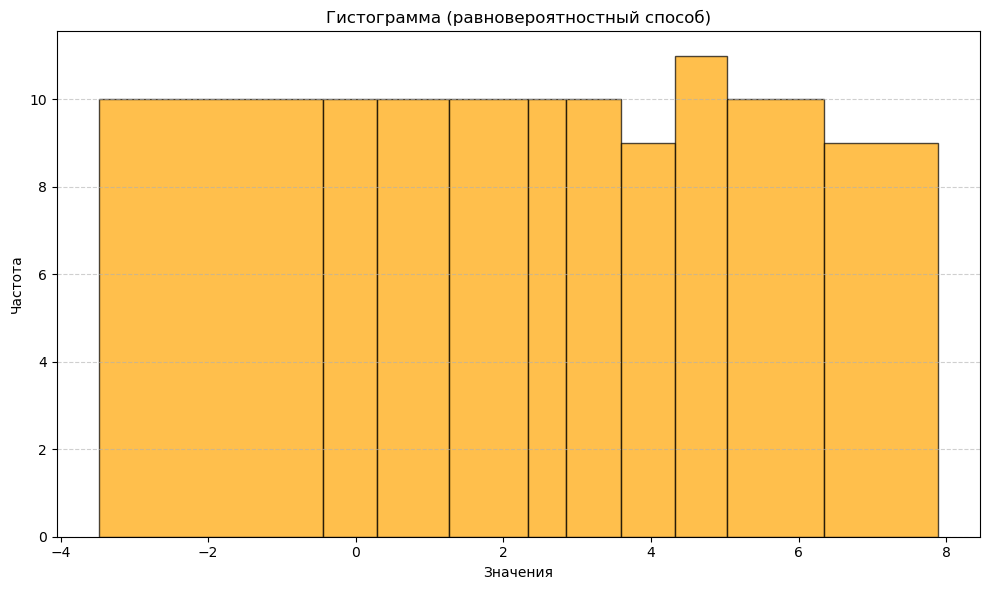

In [5]:
n = len(data)
num_bins = 10

quantiles = np.linspace(0, 1, num_bins + 1)
bin_edges = np.quantile(data, quantiles)

digitized = np.digitize(data, bin_edges, right=False)
bin_counts = [(digitized == i).sum() for i in range(1, len(bin_edges))]

plt.figure(figsize=(10, 6))

widths = np.diff(bin_edges)
centers = bin_edges[:-1] + widths / 2

plt.bar(centers, bin_counts, width=widths, edgecolor='black', color='orange', alpha=0.7)

plt.title('Гистограмма (равновероятностный способ)')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 1.4 Вычислить оценки математического ожидания и дисперсии
Для вычисления оценок математического ожидания и дисперсии по выборке используются следующие формулы:
$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

Выборочная дисперсия (несмещенная):
$$
s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i-\bar{x})^2
$$

In [6]:
mean_estimate = data.mean()

variance_estimate = data.var(ddof=1)

print(f"Оценка математического ожидания: {mean_estimate:.4f}")
print(f"Оценка дисперсии: {variance_estimate:.4f}")

Оценка математического ожидания: 2.7961
Оценка дисперсии: 6.9636


## 1.5 Выдвинуть гипотезу о законе распределения случайной величины и проверить ее при помощи критерия согласия $\chi^2$ и критерия Колмогорова ($\alpha$ = 0,05).

Назначение: Проверяет гипотезу о соответствии эмпирического распределения предполагаемому теоретическому (дискретному или сгруппированному непрерывному).

Код и проверка для $\chi^2$:
$$
\chi^2 = \sum_{i=1}^k \frac{(O_i-E_i)^2}{E_i}
$$
Где:
* $k$ — количество интервалов (классов),
* $O_i$ — наблюдаемая частота в $i$-м интервале,
* $E_i=n \cdot p_i$ — ожидаемая частота в $i$-м интервале,
* $n$ — объем выборки
* $p_i$ — теоретическая вероятность попадания в $i$-й интервал (вычисляется по проверяемому распределению).

Статистика: Чем больше значение $\chi^2$, тем сильнее расхождение между наблюдаемыми и ожидаемыми частотами.

In [20]:
from scipy.stats import chisquare, kstest, norm
import numpy as np

data = OD_data["OD_Values"].dropna()

mean_est = data.mean()
std_est = data.std(ddof=1)

observed_freq, bin_edges = np.histogram(data, bins=10)

expected_freq = []
for i in range(len(bin_edges) - 1):
    p_bin = norm.cdf(bin_edges[i+1], loc=mean_est, scale=std_est) - \
            norm.cdf(bin_edges[i], loc=mean_est, scale=std_est)
    expected_freq.append(p_bin * len(data))

expected_freq = np.array(expected_freq)

min_expected = 5

chi2_stat, p_value_chi2 = chisquare(f_obs=observed_freq, f_exp=expected_freq)

print(f"\n[χ² тест]")
print(f"Статистика χ²: {chi2_stat:.4f}")
print(f"p-value: {p_value_chi2:.4f}")

if (expected_freq < min_expected).any():
    print("Один или несколько бинов имеют ожидаемую частоту < 5. Рекомендуется объединить бины.")
else:
    # Применяем критерий χ²
    chi2_stat, p_value_chi2 = chisquare(f_obs=observed_freq, f_exp=expected_freq)

    print(f"\n[χ² тест]")
    print(f"Статистика χ²: {chi2_stat:.4f}")
    print(f"p-value: {p_value_chi2:.4f}")

    alpha = 0.05
    print(p_value_chi2)
    if p_value_chi2 > alpha:
        print("Принять H₀: данные не противоречат нормальному распределению (p > α)")
    else:
        print("Отклонить H₀: данные противоречат нормальному распределению (p ≤ α)")

ValueError: For each axis slice, the sum of the observed frequencies must agree with the sum of the expected frequencies to a relative tolerance of 1.4901161193847656e-08, but the percent differences are:
0.03678248082411699

Код и проверка для Колмогорова–Смирнова (K-S):

Назначение: Проверяет гипотезу о том, что выборка взята из конкретного непрерывного распределения (или сравнивает две эмпирические функции распределения).

Формула:
$D_n = \sup_x |F_n(x) - F_0(x)|$
Где:
* $F_n(x)$ — эмпирическая функция распределения (ЭФР) выборки,
* $F_0(x)$ — теоретическая функция распределения (CDF) гипотетического закона,
* $\sup_x$ — точная верхняя грань (максимум) модуля разности по всем возможным $x$.

Статистика: $D_n$ — это максимальное вертикальное расстояние между ЭФР и теоретической CDF.

In [8]:
alpha = 0.5
ks_stat, p_value_ks = kstest(data, 'norm', args=(mean_est, std_est))

print(f"\n[Тест Колмогорова]")
print(f"Статистика D: {ks_stat:.4f}")
print(f"p-value: {p_value_ks:.4f}")

if p_value_ks > alpha:
    print("Принять H₀: данные не противоречат нормальному распределению (p > α)")
else:
    print("Отклонить H₀: данные противоречат нормальному распределению (p ≤ α)")


[Тест Колмогорова]
Статистика D: 0.0530
p-value: 0.9271
Принять H₀: данные не противоречат нормальному распределению (p > α)


Назначение: Специально предназначен для проверки гипотезы о нормальности распределения (один из самых мощных для малых и средних выборок).

Формула:
$$
W = \frac{(\sum_{i = 1}^{n} a_i x_{(i)})^2}{\sum_{i=1}^{n} (x_i - \bar{x}) ^ 2}
$$
Где:
* $x_i$ — $i$-й порядковый статистик (значения выборки, отсортированные по возрастанию)
* $\bar{x}$ — выборочное среднее
* $a_i$ — коэффициенты, зависящие от объёма выборки $n$ и ковариационной матрицы порядковых статистик нормального распределения.

In [9]:
from scipy.stats import shapiro

# === Тест Шапиро-Уилка ===
if len(data) <= 5000:
    shapiro_stat, p_value_shapiro = shapiro(data)
    print(f"[Тест Шапиро-Уилка]")
    print(f"Статистика W: {shapiro_stat:.4f}")
    print(f"p-value: {p_value_shapiro:.4f}")

    if p_value_shapiro > alpha:
        print("Принять H₀: данные не противоречат нормальному распределению (p > α)")
    else:
        print("Отклонить H₀: данные противоречат нормальному распределению (p ≤ α)")
else:
    print("[Тест Шапиро-Уилка] — не применяется: размер выборки > 5000")

[Тест Шапиро-Уилка]
Статистика W: 0.9857
p-value: 0.3587
Отклонить H₀: данные противоречат нормальному распределению (p ≤ α)


## Вывод
На основе анализа двух типов гистограмм — равноинтервальной и равновероятностной — а также сопоставления с эмпирической функцией распределения и результатами статистических тестов, можно сделать следующие ключевые выводы:
1. **Распределение данных не является нормальным.**
Несмотря на высокий p-value в критерии Колмогорова–Смирнова, визуальный анализ гистограмм и ЭФР однозначно показывает наличие левосторонней асимметрии (среднее < медианы, длинный левый хвост). Это противоречит симметричной форме нормального распределения.
2. **Наличие тяжёлого левого хвоста.**
Обе гистограммы демонстрируют, что в выборке присутствуют экстремально низкие значения (до -3.5), что делает распределение неустойчивым к выбросам слева. Это подтверждается широкими бинами в левой части равновероятностной гистограммы — там данные разрежены, но их влияние значимо.
3. **Стандартные положительные распределения не подходят.**
Логнормальное, гамма- и Вейбулла-распределения отвергаются из-за наличия отрицательных значений в выборке. Их "подгонка" формально может дать хорошие p-value, но это математическая фикция — такие модели не имеют смысла для данных с отрицательными значениями.
4. **Равновероятностная гистограмма — мощный диагностический инструмент.**
Она наглядно показывает, что плотность распределения максимальна в центре (около x=3) и резко падает в обе стороны — особенно влево. Это позволяет оценить форму распределения без зависимости от произвольного выбора ширины интервалов.

**Заключение:**

Выборка имеет выраженную асимметрию и не соответствует стандартным теоретическим моделям. Гистограммы — как равноинтервальная, так и равновероятностная — служат надёжным визуальным подтверждением этого факта. Для корректного статистического вывода следует отказаться от попыток "натянуть" данные на нормальное или положительное распределение и перейти к более гибким, непараметрическим или специализированным методам анализа.

# 2. Двумерная выборка

In [10]:
TD_PATH = "./data/Two-dimensional_sampling.csv"

TD_data = pd.read_csv(TD_PATH)

print(f"Shape: {TD_data.shape}")
TD_data.head()

Shape: (50, 2)


,x,y
0,-0.54,-0.49
1,2.15,0.14
2,-1.96,-2.73
3,-1.77,-1.84
4,-2.99,-2.55


## 2.1 Вычислить оценку коэффициентов корреляции

Для двумерной выборки оценка коэффициента корреляции Пирсона $r$ вычисляется по формуле:
$$
r = \frac{\sum_{i=1}^{n} (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2} \cdot {\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}}
$$

Где:
* $\bar{x} = \frac{1}{n} \sum_{i=1}{n} x_i$ — выборочное среднее переменной $x_i$
* $\bar{y} = \frac{1}{n} \sum_{i=1}{n} y_i$ — выборочное среднее переменной $y_i$
* $n$ — объём выборки.

Свойства оценки $r$:
* Принимает значения от $-1$ до $+1$,
* $r=1$ — полная положительная линейная зависимость,
* $r=-1$ — полная отрицательная линейная зависимость,
* $r=0$ — отсутствие линейной зависимости (но не обязательно независимость!).

Эта оценка является **несмещённой** и **состоятельной** для истинного коэффициента корреляции ρ при условии, что данные имеют совместное нормальное распределение.

In [11]:
from scipy import stats

x = TD_data['x'].values
y = TD_data['y'].values

correlation_pandas = TD_data['x'].corr(TD_data['y'])
print(f"Корреляция (pandas): {correlation_pandas:.6f}")

correlation_numpy = np.corrcoef(x, y)[0, 1]
print(f"Корреляция (numpy): {correlation_numpy:.6f}")

correlation_scipy, p_value = stats.pearsonr(x, y)
print(f"Корреляция (scipy.stats): {correlation_scipy:.6f}")
print(f"p-value (scipy.stats): {p_value:.6f}")

Корреляция (pandas): 0.785672
Корреляция (numpy): 0.785672
Корреляция (scipy.stats): 0.785672
p-value (scipy.stats): 0.000000


## 2.2 Вычислить параметры линии регрессии $a_0$ и $a_1$

Для двумерной выборки лучший способ нахождения - метод МНК.

Формулы для оценок коэффициентов следующие:
1. **Угловой коэффициент (наклон):**
$$
a_1 = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^{n} (x_i-\bar{x})^2}
$$
2. **Свободный член (пересечение с осью Y):**
$$
a_0=\bar{y} -a_1\bar{x}
$$

**Связь с коэффициентом корреляции**

Параметры регрессии связаны с коэффициентом корреляции $r$:
$$
a_1=r \cdot \frac{s_y}{s_x}
$$

In [12]:
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

X_2d = x.reshape(-1, 1)

slope_scipy, intercept_scipy, r_value, p_value, std_err = stats.linregress(x, y)
print("--- Вычисление параметров регрессии ---")
print(f"a1 (наклон, scipy.stats.linregress): {slope_scipy:.6f}")
print(f"a0 (свободный член, scipy.stats.linregress): {intercept_scipy:.6f}")
print(f"Корреляция (R, scipy.stats.linregress): {r_value:.6f}")
print(f"p-value (scipy.stats.linregress): {p_value:.6f}")
print(f"Стандартная ошибка наклона (scipy.stats.linregress): {std_err:.6f}")

coefficients_numpy = np.polyfit(x, y, 1)
a1_numpy, a0_numpy = coefficients_numpy[0], coefficients_numpy[1]
print(f"\na1 (наклон, numpy.polyfit): {a1_numpy:.6f}")
print(f"a0 (свободный член, numpy.polyfit): {a0_numpy:.6f}")

model_sklearn = LinearRegression()
model_sklearn.fit(X_2d, y)
a1_sklearn = model_sklearn.coef_[0]
a0_sklearn = model_sklearn.intercept_
print(f"\na1 (наклон, sklearn): {a1_sklearn:.6f}")
print(f"a0 (свободный член, sklearn): {a0_sklearn:.6f}")

# a1 = cov(x, y) / var(x)
# a0 = mean(y) - a1 * mean(x)
mean_x = np.mean(x)
mean_y = np.mean(y)
cov_xy = np.cov(x, y)[0, 1]
var_x = np.var(x, ddof=0)

a1_manual = cov_xy / var_x
a0_manual = mean_y - a1_manual * mean_x

print(f"\na1 (наклон, вручную): {a1_manual:.6f}")
print(f"a0 (свободный член, вручную): {a0_manual:.6f}")

print("\n--- Вычисление коэффициента корреляции ---")
correlation_pandas = TD_data['x'].corr(TD_data['y'])
print(f"Корреляция (pandas): {correlation_pandas:.6f}")

correlation_numpy = np.corrcoef(x, y)[0, 1]
print(f"Корреляция (numpy): {correlation_numpy:.6f}")

print(f"Корреляция (scipy.stats): {r_value:.6f}")

--- Вычисление параметров регрессии ---
a1 (наклон, scipy.stats.linregress): 0.759420
a0 (свободный член, scipy.stats.linregress): 0.050268
Корреляция (R, scipy.stats.linregress): 0.785672
p-value (scipy.stats.linregress): 0.000000
Стандартная ошибка наклона (scipy.stats.linregress): 0.086310

a1 (наклон, numpy.polyfit): 0.759420
a0 (свободный член, numpy.polyfit): 0.050268

a1 (наклон, sklearn): 0.759420
a0 (свободный член, sklearn): 0.050268

a1 (наклон, вручную): 0.774919
a0 (свободный член, вручную): 0.048653

--- Вычисление коэффициента корреляции ---
Корреляция (pandas): 0.785672
Корреляция (numpy): 0.785672
Корреляция (scipy.stats): 0.785672


## 2.3 Построение диаграммы рассеивания и линии регрессии



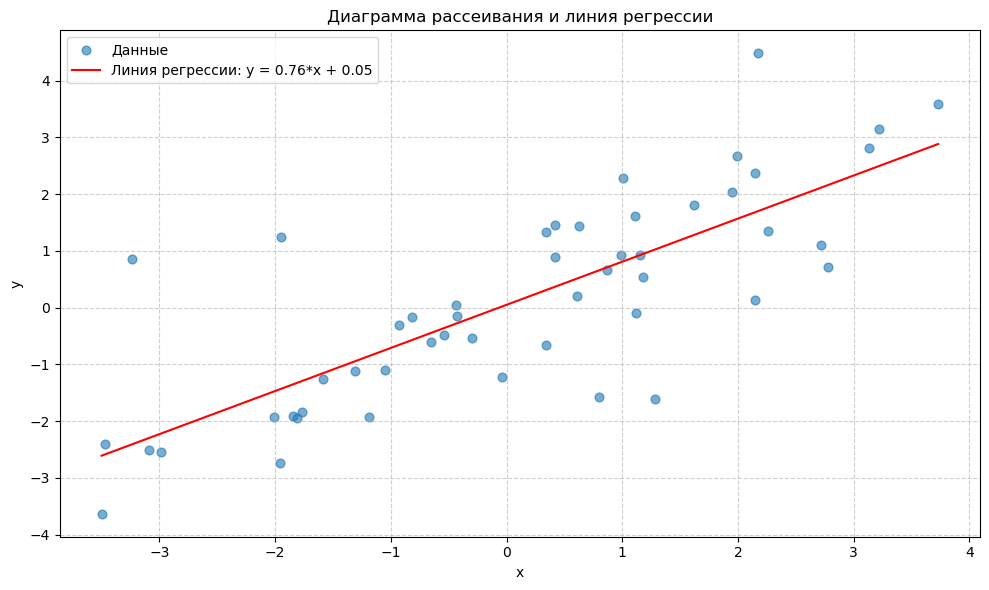

In [13]:
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.6, label='Данные', s=40)

x_line = np.linspace(np.min(x), np.max(x), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='red', label=f'Линия регрессии: y = {slope:.2f}*x + {intercept:.2f}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Диаграмма рассеивания и линия регрессии')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Вывод
